# P06 — Linear Regression from scratch  *(the first reflex: draw the line)*

> **The story so far.** The mind understands the shape of a lesson and knows not to merely memorise
> ([P05](P05_The_ML_Mindset.ipynb)). Until now, though, *we* set its numbers by hand — it hasn't yet
> learned anything on its own. Today it grows its first true **reflex**. Like a child learning to
> read a thermostat — colder rooms, lower needle; warmer rooms, higher — it discovers the straight
> line hiding in the data, all by itself. And it does so with the heartbeat we forged back in P02:
> **predict → measure how wrong → step downhill**, over and over, until the line snaps into place.
> This is the very same loop that, a billion parameters larger, trains the GPT. Watch it beat here.

Linear regression fits the best straight line through data: `prediction = w·x + b`. It's the
"hello world" of machine learning, and crucially it has the **exact same training loop** as a deep
neural network — predict, measure loss, compute gradients, step downhill. Master it here with
two parameters you can watch, and the GPT's training loop later will feel familiar.

We use everything so far: the model is a dot product (P01), the loss is built from squared error
(P03's expectation), and we minimise it with gradient descent (P02). Every gradient is derived by
hand, then confirmed numerically, then the final line is checked against scikit-learn.

## B1 — The model and the loss (MSE)

An estate agent eyeballing a house does something simple: bigger means pricier, by roughly so-many
dollars per square foot, plus a baseline. That's a straight line — a slope and a starting point. To
judge how good the agent's line is, we add up how far each real sale lands from the line's guess,
and square those gaps so big misses sting more. The mind's first model and its first scorecard.

**Model (one feature):** `ŷ = w·x + b`, with two parameters `w` (slope) and `b` (intercept).

**Loss — Mean Squared Error:** average of the squared gaps between prediction and truth:
```
MSE = (1/n) · Σ (ŷᵢ − yᵢ)²
```
Squaring makes all errors positive and punishes big misses harder. Lower MSE = better line.

**Worked example by hand.** Data: `(x,y) = (1,2), (2,3), (3,5)`. Try `w=1, b=1` → `ŷ = x+1`:
```
ŷ = [2, 3, 4],  errors (ŷ−y) = [0, 0, −1]
MSE = (0² + 0² + (−1)²) / 3 = 1/3 = 0.333
```

In [1]:
import numpy as np
x = np.array([1.0, 2.0, 3.0])
y = np.array([2.0, 3.0, 5.0])

def predict(x, w, b): return w*x + b
def mse(w, b):        return np.mean((predict(x, w, b) - y)**2)

w, b = 1.0, 1.0
print("predictions ŷ :", predict(x, w, b), " (hand [2,3,4])")
print("errors ŷ−y    :", predict(x, w, b) - y, " (hand [0,0,-1])")
print("MSE           :", round(mse(w, b), 3), " (hand 0.333)")

predictions ŷ : [2. 3. 4.]  (hand [2,3,4])
errors ŷ−y    : [ 0.  0. -1.]  (hand [0,0,-1])
MSE           : 0.333  (hand 0.333)


## B2 — The gradient of the loss (derived by hand)

A bad guess isn't enough — the mind needs to know *which way to nudge* the slope and the baseline to
do better, exactly like the foggy-hillside walker of P02 feeling for downhill. So we ask the loss
its two slopes: "if I lift the slope a hair, does my error rise or fall? what about the baseline?"
Those two answers are the gradients, and they point the way to a better line.

To improve `w` and `b` we need the slope of MSE with respect to each — the gradients. Using the
chain rule (P02) on `MSE = (1/n)Σ(w·x + b − y)²`:
```
∂MSE/∂w = (2/n) · Σ (ŷᵢ − yᵢ)·xᵢ
∂MSE/∂b = (2/n) · Σ (ŷᵢ − yᵢ)
```
In words: the gradient is the average error, weighted by the input for `w`. The error term
`(ŷ − y)` appears in both — that recurring "prediction minus truth" signal drives all of learning.

**Worked example by hand** at `w=1, b=1` (errors were `[0, 0, −1]`, `x=[1,2,3]`):
```
∂/∂w = (2/3)·(0·1 + 0·2 + (−1)·3) = (2/3)·(−3) = −2.0
∂/∂b = (2/3)·(0 + 0 + (−1))       = (2/3)·(−1) = −0.667
```
Both negative → loss decreases if we *increase* `w` and `b`. Gradient descent does exactly that.

In [2]:
import numpy as np
x = np.array([1.0, 2.0, 3.0]); y = np.array([2.0, 3.0, 5.0])
def predict(x,w,b): return w*x+b
def mse(w,b): return np.mean((predict(x,w,b)-y)**2)

def grads(w, b):
    err = predict(x, w, b) - y          # (ŷ − y), the signal that drives learning
    dw = 2*np.mean(err * x)
    db = 2*np.mean(err)
    return dw, db

w, b = 1.0, 1.0
dw, db = grads(w, b)
print("hand grads: dw=-2.000, db=-0.667")
print("code grads: dw=%.3f, db=%.3f" % (dw, db))

# numeric check (P02 finite differences) — trust nothing un-verified
h = 1e-5
dw_num = (mse(w+h,b)-mse(w-h,b))/(2*h)
db_num = (mse(w,b+h)-mse(w,b-h))/(2*h)
print("numeric   : dw=%.3f, db=%.3f  <- confirms the hand derivation" % (dw_num, db_num))

hand grads: dw=-2.000, db=-0.667
code grads: dw=-2.000, db=-0.667
numeric   : dw=-2.000, db=-0.667  <- confirms the hand derivation


## B3 — Training: gradient descent until the line fits

Here is the moment the mind learns on its own for the first time. Like that thermostat patiently
nudging the dial — too cold, edge up; too warm, edge down — it guesses a line, measures how wrong it
is, nudges the slope and baseline a touch downhill, and repeats. No magic, just the same small step
taken hundreds of times until the line settles onto the data. This loop is the heartbeat of *all* of
deep learning, GPT included.

Now the loop from P02/P05, run for real:
```
repeat:
    ŷ      = w·x + b           # forward: predict
    grads  = ∂MSE/∂w, ∂MSE/∂b  # backward: how to improve
    w     -= lr · ∂MSE/∂w      # step downhill
    b     -= lr · ∂MSE/∂b
```
This **predict → loss → grad → step** loop is the heartbeat of *all* of deep learning, GPT
included. Watch the loss fall and the parameters settle.

In [3]:
import numpy as np
x = np.array([1.0, 2.0, 3.0]); y = np.array([2.0, 3.0, 5.0])
def predict(x,w,b): return w*x+b
def mse(w,b): return np.mean((predict(x,w,b)-y)**2)
def grads(w,b):
    err = predict(x,w,b)-y
    return 2*np.mean(err*x), 2*np.mean(err)

w, b, lr = 0.0, 0.0, 0.1                 # start from nothing
print(f"{'epoch':>5} {'w':>7} {'b':>7} {'MSE':>8}")
for epoch in range(201):
    dw, db = grads(w, b)
    w -= lr*dw; b -= lr*db
    if epoch % 40 == 0:
        print(f"{epoch:>5} {w:>7.3f} {b:>7.3f} {mse(w,b):>8.4f}")
print(f"\nlearned line: y = {w:.3f}·x + {b:.3f}")

epoch       w       b      MSE
    0   1.533   0.667   0.2163
   40   1.456   0.434   0.0570
   80   1.483   0.371   0.0558
  120   1.494   0.348   0.0556
  160   1.498   0.339   0.0556
  200   1.499   0.335   0.0556

learned line: y = 1.499·x + 0.335


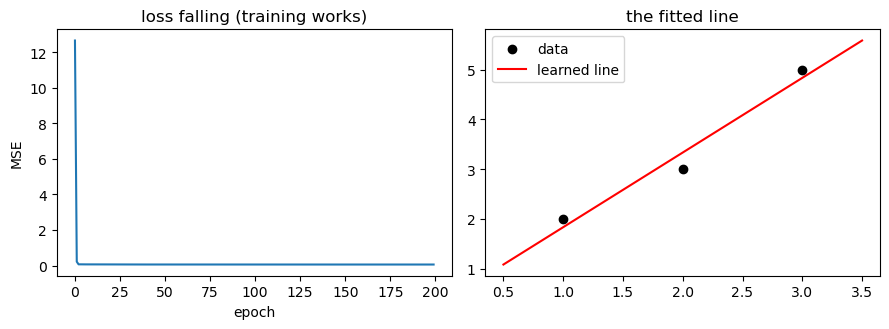

final w=1.499, b=0.335


In [4]:
import numpy as np, matplotlib.pyplot as plt
x = np.array([1.0,2.0,3.0]); y = np.array([2.0,3.0,5.0])
def grads(w,b):
    err=(w*x+b)-y; return 2*np.mean(err*x), 2*np.mean(err)
w,b,lr=0.0,0.0,0.1; losses=[]
for _ in range(200):
    losses.append(np.mean(((w*x+b)-y)**2)); dw,db=grads(w,b); w-=lr*dw; b-=lr*db

fig,(a1,a2)=plt.subplots(1,2,figsize=(9,3.4))
a1.plot(losses); a1.set_title("loss falling (training works)"); a1.set_xlabel("epoch"); a1.set_ylabel("MSE")
xx=np.linspace(0.5,3.5,10)
a2.scatter(x,y,c="black",zorder=3,label="data"); a2.plot(xx,w*xx+b,"r",label="learned line")
a2.set_title("the fitted line"); a2.legend()
plt.tight_layout(); plt.show()
print(f"final w={w:.3f}, b={b:.3f}")

## B4 — Verify against scikit-learn (the closed-form answer)

We never trust the mind's homework without an answer key. Linear regression is rare in having an
*exact* mathematical solution — no stepping required — and scikit-learn computes it directly. If the
line our patient downhill-walk arrived at matches that exact answer, we know the from-scratch
training was honest.

Linear regression is special: it has an exact mathematical solution (no iteration needed).
scikit-learn computes that. If our gradient-descent line matches sklearn's, our from-scratch
training was correct.

In [5]:
import numpy as np
from sklearn.linear_model import LinearRegression
x = np.array([1.0,2.0,3.0]); y = np.array([2.0,3.0,5.0])

# our trained values (rerun the loop briefly)
def grads(w,b):
    err=(w*x+b)-y; return 2*np.mean(err*x), 2*np.mean(err)
w,b,lr=0.0,0.0,0.1
for _ in range(2000): dw,db=grads(w,b); w-=lr*dw; b-=lr*db

reg = LinearRegression().fit(x.reshape(-1,1), y)
print("from scratch : w=%.4f  b=%.4f" % (w, b))
print("scikit-learn : w=%.4f  b=%.4f" % (reg.coef_[0], reg.intercept_))
print("-> they match: our hand-built training found the mathematically optimal line.")

from scratch : w=1.5000  b=0.3333
scikit-learn : w=1.5000  b=0.3333
-> they match: our hand-built training found the mathematically optimal line.


## B5 — Many features at once (the matrix form)

A real house isn't priced on size alone — bedrooms, age, location all weigh in. The mind doesn't
need a new idea for this; it just gives each feature its own slope and adds them up, which is exactly
the matrix×vector sense from P01 firing as one layer. The training loop doesn't change at all — only
the shapes grow. This is, quite literally, what a `Linear` layer in a neural net does.

Real problems have many features. The model becomes `ŷ = X @ w + b` — a single matrix multiply
(P01, B3) producing one prediction per row. The training loop is *identical*; only shapes change.
This vectorised form is exactly how a `Linear` layer in a neural net works.

In [6]:
import numpy as np
rng = np.random.default_rng(0)
X = rng.normal(size=(50, 3))                  # 50 samples, 3 features
true_w = np.array([2.0, -1.0, 0.5]); true_b = 4.0
y = X @ true_w + true_b + rng.normal(0, 0.1, size=50)   # data from a known line + noise

w = np.zeros(3); b = 0.0; lr = 0.1; n = len(y)
for _ in range(2000):
    err = (X @ w + b) - y                     # (50,)
    w -= lr * (2/n) * (X.T @ err)             # gradient for all 3 weights at once
    b -= lr * (2/n) * err.sum()
print("true  w =", true_w, " b =", true_b)
print("learnt w =", np.round(w, 3), " b =", round(b, 3))
print("-> recovered the true parameters from noisy data using the same predict/loss/grad/step loop.")

true  w = [ 2.  -1.   0.5]  b = 4.0
learnt w = [ 2.016 -1.015  0.506]  b = 3.99
-> recovered the true parameters from noisy data using the same predict/loss/grad/step loop.


## Recap — the loop you'll use forever

| Piece | This notebook | Same thing in a GPT |
|-------|---------------|---------------------|
| Model | `ŷ = w·x + b` | stacked attention + linear layers |
| Loss | MSE `(1/n)Σ(ŷ−y)²` | cross-entropy (P03) |
| Gradient | hand-derived `∂MSE/∂w,∂b` | autograd / backprop (P11) |
| Update | `w -= lr·grad` | same, millions of params |
| Verify | matches sklearn | matches PyTorch |

## Common mistakes
1. **Learning rate too high** → loss diverges to NaN; too low → crawls. Tune it first (P12 formalises).
2. **Forgetting the `2/n`** in the gradient. It only rescales steps (the LR can absorb it), but be consistent.
3. **Not normalising features.** Features on very different scales make gradient descent zig-zag (P04's standardisation fixes it).
4. **Reading `(ŷ − y)` backwards.** It's prediction minus truth; the sign sets the step direction.
5. **Expecting iteration to beat the closed form** for plain linear regression — it only *matches* it; iteration matters when there's no closed form (neural nets).

## Exercises (do them in new code cells)
1. Change the data to `(1,3),(2,5),(3,7)` (a perfect line `y=2x+1`). Does training find `w≈2, b≈1`? Is the final MSE ~0?
2. Set `lr=1.5` in B3. What happens to the loss, and what does that teach you?
3. Derive `∂MSE/∂b` by hand for the 3-point dataset at `w=2, b=0`; verify numerically.
4. In B5, change `true_w` to `[5, 5, 5]`. Does the loop still recover it? How many epochs does it take?
5. Add L2 weight decay: subtract an extra `lr·0.1·w` in the update. How does it nudge the learned `w`? (Preview of P08.)

---

**The mind has its first reflex: it can learn the line that explains the world.** But a line answers
"how much?" — and so much of life is instead "which one?": spam or not, sick or well, yes or no.
Next, in [P07 — Logistic Regression & Classification](P07_Logistic_Regression.ipynb), the mind
learns to **take a side** — bending its line through an S-curve to turn a number into a decision,
and in the process quietly building its very first *neuron*.